In [6]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Step 1: Read the input image
img = cv2.imread("colourful.jpg")

# Check whether image is loaded
if img is None:
    print("Error: Image not found.")
    exit()


In [8]:
# Step 2: Convert BGR to RGB for displaying
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [9]:
# ---------------------------------------------------
# Smoothing Filters
# ---------------------------------------------------

# 1. Averaging Filter
average = cv2.blur(img_rgb, (5, 5))

# 2. Weighted Averaging Filter
kernel = np.array([[1, 2, 1],
                   [2, 4, 2],
                   [1, 2, 1]], dtype=np.float32)

kernel = kernel / kernel.sum()

weighted = cv2.filter2D(img_rgb, -1, kernel)

# 3. Gaussian Filter
gaussian = cv2.GaussianBlur(img_rgb, (5, 5), 0)

# 4. Median Filter
median = cv2.medianBlur(img_rgb, 5)

# ---------------------------------------------------
# Sharpening Filters
# ---------------------------------------------------

# 5. Laplacian Sharpening using Kernel
laplacian_kernel = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])

laplacian_sharp = cv2.filter2D(img_rgb, -1, laplacian_kernel)

# 6. Laplacian Operator
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

laplacian_operator = cv2.Laplacian(gray, cv2.CV_64F)
laplacian_operator = np.uint8(np.absolute(laplacian_operator))


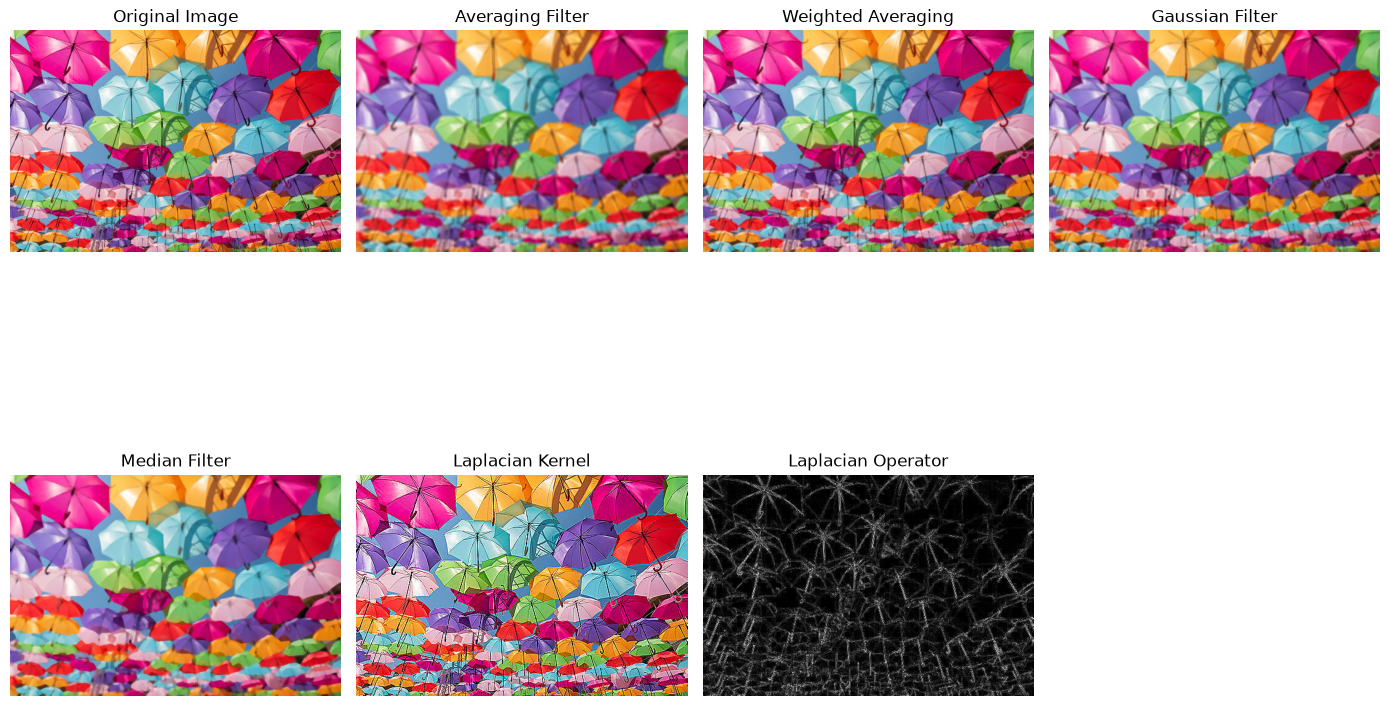

In [10]:
# ---------------------------------------------------
# Display Results
# ---------------------------------------------------

plt.figure(figsize=(14, 10))

plt.subplot(2, 4, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(average)
plt.title("Averaging Filter")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(weighted)
plt.title("Weighted Averaging")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(gaussian)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(median)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(laplacian_sharp)
plt.title("Laplacian Kernel")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(laplacian_operator, cmap="gray")
plt.title("Laplacian Operator")
plt.axis("off")

plt.tight_layout()
plt.show()